In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
class WindowDataset(Dataset):
    def __init__(self,_data,_window):
        #_data : tensor, array
        #_window : 구간의 크기
        self.data=_data
        self.window=_window
        #DataLoader에서 사용이 가능한 인덱스의 최대값 
        self.n=len(_data) - _window

    def __len__(self):
        return self.n

    def __getitem__(self,idx):
        #idx : 0 ~ self.n-1 사이의 정수를 대입 (DataLoader에서 자동으로 대입)
        x = self.data[idx:idx + self.window]
        y = self.data[idx + self.window]
        return x, y


In [34]:
# RNN 모델 정의 
class RNNModel(nn.Module):
    def __init__(self,
                 input_size, 
                 hidden_size = 64, 
                 num_layers = 1, 
                 dropout = 0.0, 
                 nonlinearity = 'tanh', 
                 bidirectional = False):
        super(RNNModel, self).__init__()
        # super().__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            dropout = dropout, 
            nonlinearity = nonlinearity, 
            bidirectional = bidirectional, 
            # batch_first는 기본이 Fasle였던걸 까먹고 안 넣고 있었네요 
            # 죄송합니다. 
            # batch_first가 False인 경우, 입력 데이터(구간의 개수, 배치 크기, 입력 데이터 feature의 수)
            # (배치 크기, 구간의 쿠기, 입력 feature의 수) -> True로 변경
            batch_first = True
        )

        # output_feature가 역방향을 포함한다면 2배로 늘어난다. 
        if bidirectional:
            hidden_size *= 2
        print(f"hidden_size : {hidden_size}")
        self.model = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        result = self.model(last_hidden)
        return result

In [35]:
#모델 학습 시 검증 데이터를 이용하여 모델의 성능을 평가할 수 있도록 검증 데이터 평가 함수

@torch.no_grad()
def evaluate_mse(dataloader,model):
    #dataloader : 검증 데이터셋의 dataloader
    model.eval()
    total_loss=0
    total_n=0
    for x, y in dataloader:
        x=x.float()
        y=y.float()
        pred=model(x)
        loss=nn.MSELoss()(pred,y)
        total_loss+=loss.item()*x.size(0)
        total_n+=x.size(0)
    return total_loss / max(total_n,1)


In [36]:
df=pd.read_csv('../../csv/AAPL.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   object 
 1   Open       9714 non-null   float64
 2   High       9714 non-null   float64
 3   Low        9714 non-null   float64
 4   Close      9714 non-null   float64
 5   Adj Close  9714 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 531.4+ KB


In [37]:
df.dropna(inplace=True)

In [38]:
#수정종가, 날짜 데이터만 추출
df=df[['Date','Adj Close']]

In [39]:
values=df[['Adj Close']].values
values

array([[  0.410525],
       [  0.389106],
       [  0.360548],
       ...,
       [199.460007],
       [198.779999],
       [199.169998]], shape=(9713, 1))

In [40]:
df['Adj Close'].values.reshape(-1,1)

array([[  0.410525],
       [  0.389106],
       [  0.360548],
       ...,
       [199.460007],
       [198.779999],
       [199.169998]], shape=(9713, 1))

In [41]:
#75 : 25 비율로 학습, 검증 데이터 분할
split_idx=int(len(values)*0.75)
split_idx

7284

In [42]:
train_data=values[:split_idx]
test_data=values[split_idx:]

In [43]:
#MinMaxScaler로 데잍 정규화
scaler=MinMaxScaler()
train_sc=scaler.fit_transform(train_data)
test_sc=scaler.transform(test_data)

test_sc

array([[0.93723805],
       [0.956606  ],
       [0.91811525],
       ...,
       [7.80873011],
       [7.78208726],
       [7.7973675 ]], shape=(2429, 1))

In [44]:
#스케일링이 완료된 데이터를 Tensor로 변환
train_sc = torch.tensor(train_sc, dtype=torch.float32)
test_sc = torch.tensor(test_sc, dtype=torch.float32)

In [45]:
#WindowDataset에 데이터 대입
train_ds=WindowDataset(train_sc,_window=60)
test_ds=WindowDataset(test_sc,_window=60)

In [46]:
#Dataset을 DataLoader로 생성
train_dl=DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
test_dl=DataLoader(test_ds, batch_size=128, shuffle=False, drop_last=False)

In [55]:
aapl_model = RNNModel(
    input_size = 1,
    hidden_size=128
)
criterion = nn.MSELoss()
optimizer = optim.Adam(aapl_model.parameters(), lr = 0.001)

hidden_size : 128


In [56]:
# 모델 학습 
train_history, test_history = [], []
for epoch in range(20):
    aapl_model.train()
    running, n_seen = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        pred = aapl_model(x)
        loss = criterion(pred, y)
        # print(x.shape, y.shape)
        # print(pred.shape, y.shape)
        # break
        optimizer.zero_grad()
        loss.backward()
        # 가중치 발산 방지 
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)
        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / n_seen
    test_mse = evaluate_mse(test_dl, aapl_model)
    train_history.append(train_mse)
    test_history.append(test_mse)
    print(f"Epoch {epoch+1} Train MSE: {round(train_mse, 8)} Test MSE: {round(test_mse, 8)}")

Epoch 1 Train MSE: 0.01385444 Test MSE: 5.53567129
Epoch 2 Train MSE: 0.00014063 Test MSE: 5.25266777
Epoch 3 Train MSE: 0.00011339 Test MSE: 5.00575079
Epoch 4 Train MSE: 0.00010859 Test MSE: 4.8065914
Epoch 5 Train MSE: 9.979e-05 Test MSE: 4.61575083
Epoch 6 Train MSE: 9.022e-05 Test MSE: 4.42317896
Epoch 7 Train MSE: 8.969e-05 Test MSE: 4.26806027
Epoch 8 Train MSE: 8.684e-05 Test MSE: 4.08845502
Epoch 9 Train MSE: 0.00010079 Test MSE: 3.95015722
Epoch 10 Train MSE: 8.762e-05 Test MSE: 3.74524362
Epoch 11 Train MSE: 9.574e-05 Test MSE: 3.64717693
Epoch 12 Train MSE: 8.496e-05 Test MSE: 3.53064222
Epoch 13 Train MSE: 8.369e-05 Test MSE: 3.46085352
Epoch 14 Train MSE: 7.837e-05 Test MSE: 3.37620247
Epoch 15 Train MSE: 7.603e-05 Test MSE: 3.26201094
Epoch 16 Train MSE: 7.389e-05 Test MSE: 3.21688244
Epoch 17 Train MSE: 8.041e-05 Test MSE: 3.1044205
Epoch 18 Train MSE: 7.209e-05 Test MSE: 2.99941437
Epoch 19 Train MSE: 7.681e-05 Test MSE: 2.99027025
Epoch 20 Train MSE: 7.847e-05 Test MS

In [57]:
#학습 및 모델을 이용하여 예측값을 확인하고 실제값과 의 차이를 그래프로 시각화
aapl_model.eval()

preds=[]
trues=[]

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()

        pred=aapl_model(x)
        preds.append(pred)
        trues.append(y.cpu())

print(preds)

[tensor([[0.9741],
        [0.9675],
        [0.9766],
        [0.9786],
        [0.9625],
        [0.9419],
        [0.9303],
        [0.9349],
        [0.9372],
        [0.9384],
        [0.9357],
        [0.9364],
        [0.9374],
        [0.9430],
        [0.9515],
        [0.9635],
        [0.9723],
        [0.9766],
        [0.9749],
        [0.9695],
        [0.9596],
        [0.9549],
        [0.9573],
        [0.9673],
        [0.9831],
        [0.9970],
        [1.0053],
        [1.0090],
        [1.0208],
        [1.0358],
        [1.0532],
        [1.0673],
        [1.0765],
        [1.0815],
        [1.0797],
        [1.0756],
        [1.0714],
        [1.0702],
        [1.0678],
        [1.0681],
        [1.0744],
        [1.0847],
        [1.0899],
        [1.0944],
        [1.0998],
        [1.1100],
        [1.1186],
        [1.1243],
        [1.1291],
        [1.1346],
        [1.1406],
        [1.1439],
        [1.1468],
        [1.1495],
        [1.1521],
        [

In [58]:
len(preds[0])

128

In [59]:
#cat() : 여러개의 텐서를 하나의 텐서로 결합
#squeeze() : 텐서의 차원 중 크기가 1인 차원을 제거
#numpy() : 텐서 타입을 numpy의 array 타입으로 전환
preds=torch.cat(preds, dim=0).squeeze(-1).numpy()
trues=torch.cat(trues, dim=0).squeeze(-1).numpy()


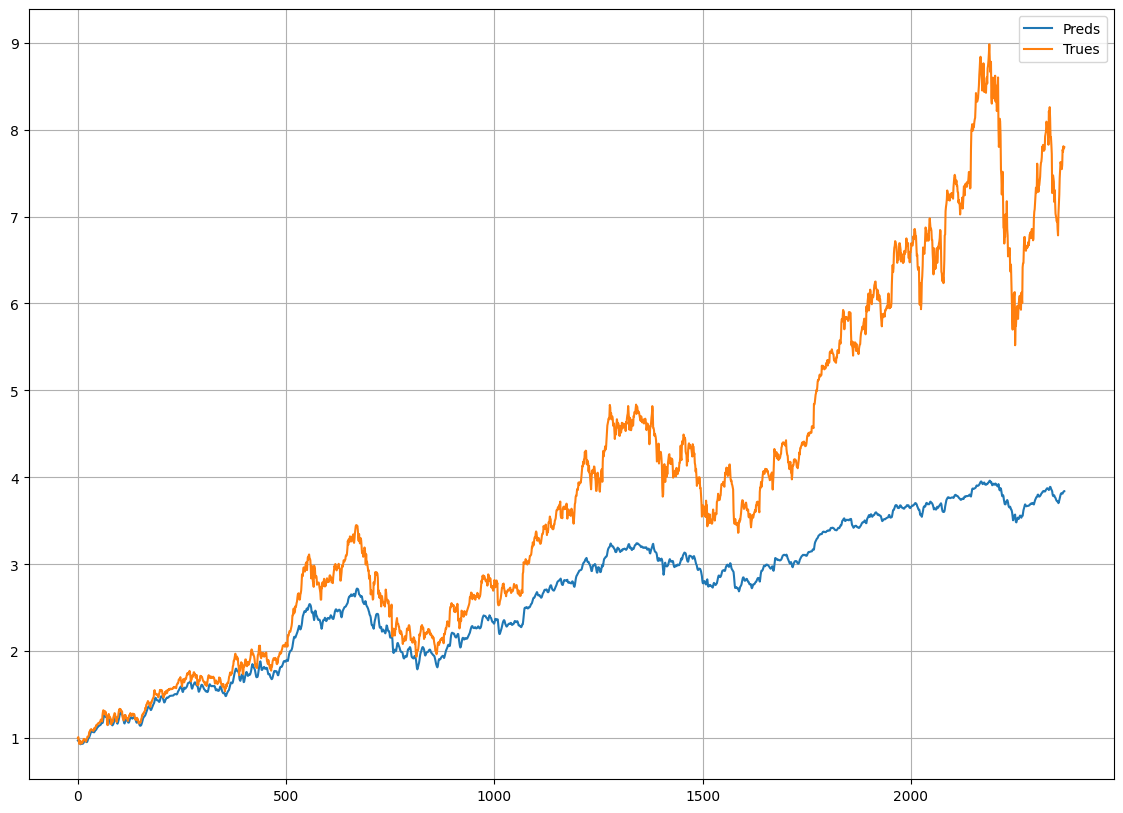

In [60]:
plt.figure(figsize=(14,10))
plt.plot(preds,label='Preds')
plt.plot(trues,label='Trues')
plt.legend()
plt.grid()
plt.show()

In [61]:
#스케일링 데이터를 원본의 데이터셋을 변환후 그래프로 시각화
pred_origin=scaler.inverse_transform(preds.reshape(-1,1)).squeeze(-1)
pred_origin

array([25.01837 , 24.850824, 25.08171 , ..., 98.02247 , 98.17658 ,
       98.19777 ], shape=(2369,), dtype=float32)

In [62]:
true_origin=scaler.inverse_transform(trues.reshape(-1,1)).squeeze(-1)

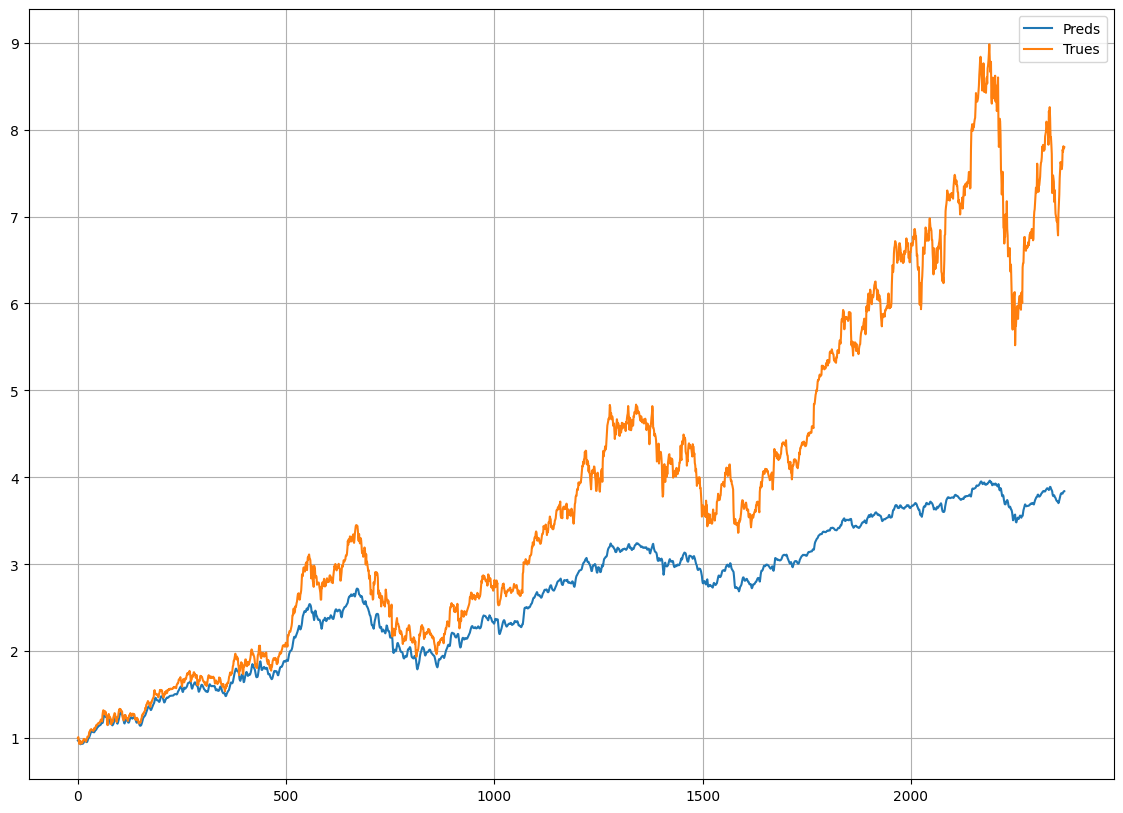

In [63]:
plt.figure(figsize=(14,10))
plt.plot(preds,label='Preds')
plt.plot(trues,label='Trues')
plt.legend()
plt.grid()
plt.show()

In [66]:
#feature의 개수를 증가하여 모델에 학습 (종가, 거래걍)
df=pd.read_csv('../../csv/AAPL.csv')
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9713 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9713 non-null   object 
 1   Open       9713 non-null   float64
 2   High       9713 non-null   float64
 3   Low        9713 non-null   float64
 4   Close      9713 non-null   float64
 5   Adj Close  9713 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), object(1)
memory usage: 607.1+ KB


In [85]:
#학습 데이터
x = df[['Adj Close','Volume']].astype(float).values
y = df[['Adj Close']].astype(float).values

In [86]:
#Scaler를 2개 생성
scaler_x=StandardScaler()
scaler_y=StandardScaler()

#데이터 80 : 20 비율로 데이터 분할
split_idx=int(len(x)*0.8)
X_train,X_test = x[:split_idx], x[split_idx:]
y_train,y_test = y[:split_idx], y[split_idx:]

#스케일링
X_train_sc=scaler_x.fit_transform(X_train)
X_test_sc=scaler_x.transform(X_test)

y_train_sc=scaler_y.fit_transform(y_train)
y_test_sc=scaler_y.transform(y_test)

In [87]:
type(X_train_sc)

numpy.ndarray

In [88]:
class windowDS(Dataset):
    def __init__(self,_x,_y,_window):
        self.x=_x
        self.y=_y
        self.window=_window
        #최대 인덱스의 값
        self.n=len(_x) - _window

    #데이터의 길이를 보여주는 함수
    def __len__(self):
        return self.n

    #데이터로더가 실제 데이터를 가져오는 함수
    def __getitem__(self, idx):
        x=self.x[idx:idx+self.window]
        y=self.y[idx+self.window]
        #현재 x, y는 array 형태이기 떄문에 torch에서 사용 불가능
        #tensor 형태로 변환
        #tensor() : 2차원 데이터를 tensor 형태로 변환 (깊은 복사)
        #from_numpy() : array 형태의 데이터를 tensor 형태로 변환 (얕은 복사)
        x_tensor = torch.from_numpy(x).float()
        y_tensor=torch.from_numpy(y).float()
        return x_tensor, y_tensor

In [89]:
#RNN 모델 정의
class RNNModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size = 64,
        num_layers=1,
        nonlinearity='tanh',
        dropout=0.0,
        bidirectional=False,
        batch_first=True
    ):
        super(RNNModel, self).__init__()
        #bidirectional이 True인 경우, hidden_size를 2배로 늘려준다.
        hidden_size=hidden_size * (2 if bidirectional == False else 1)
        self.rnn=nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        #비선형 모델 학습 -> 선형 -> 비선형 활성화 함수 추가 (다중 퍼셉트로 구조)
        self.model=nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.ReLU(),
            nn.Linear(hidden_size * 2, 1)
        )
    #순전파 함수 정의
    def forward(self,x):
        out, h_n=self.rnn(x)
        last_hidden=h_n[-1]
        result=self.model(last_hidden)
        return result

In [90]:
#구간별 데이터셋을 구성
train_ds=windowDS(X_train_sc,y_train_sc,_window=60)
test_ds=windowDS(X_test_sc, y_test_sc, _window=60)
#데이터 로더 생성
train_dl=DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
test_dl=DataLoader(test_ds,shuffle=False, drop_last=False, batch_size=128)

In [91]:
#모델 생성
aapl_model=RNNModel(input_size=2, hidden_size=128)
#손실 함수
criterion=nn.MSELoss()
#optimizer 설정
optimizer=optim.Adam(aapl_model.parameters(),lr=0.001)

In [92]:
#평가 함수 생성 (반복 학습을 하면서 검증 데이터셋을 이용한 Loss확인 함수)

#데코레이터 생성
@torch.no_grad()
def evaluate_mse(dl):
    #모델 평가 모드 전환
    aapl_model.eval()
    #전체 loss의 값, 전체 데이터의 개수 초기값 설정
    total_loss, total_n = 0.0,0

    for x, y in dl:
        x=x.float()
        y=y.float()
        pred=aapl_model(x)
        loss=criterion(pred,y)
        total_loss+=loss.item() * y.size(0)
        total_n += y.size(0)
    return total_loss / max(total_n, 1)

#loss의 변화량을 확인하기 위해 빈 리스트를 생성 (반복 학습에 따른 loss의 변화를 그래프로 시각화)
train_history, test_history = [], []
#반복 횟수 epochs : 굳이 range함수에 넣지 않고 변수로 반복 횟수르 샐정하는 이유는? 함수화할 때 매개변수로 사용
epochs=20

for epoch in range(epochs):
    #학습 모드로 전환
    aapl_model.train()
    #loss의 합계, 데이터의 개수
    total_loss, total_n = 0.0, 0

    for x, y in train_dl:
        x=x.float()
        y=y.float()

        pred=aapl_model(x)
        loss=criterion(pred,y)
        #기울기 초기화
        optimizer.zero_grad()
        #자동 미분
        loss.backward()
        #기울기 폭발 방지
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)
        #기울기를 변환
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)

    #학습 데이터 전체의 loss를 구한다.
    train_mse=total_loss / max(total_n,1)
    val_mse=evaluate_mse(test_dl)
    train_history.append(train_mse)
    test_history.append(val_mse)
    print(f'Epoch : {epoch+1}, train_mse : {round(train_mse,4)}, test_mse : {round(val_mse, 4)}')

Epoch : 1, train_mse : 0.032, test_mse : 13.4914
Epoch : 2, train_mse : 0.0018, test_mse : 12.5451
Epoch : 3, train_mse : 0.0012, test_mse : 11.922
Epoch : 4, train_mse : 0.0011, test_mse : 9.562
Epoch : 5, train_mse : 0.0014, test_mse : 8.8973
Epoch : 6, train_mse : 0.001, test_mse : 7.9941
Epoch : 7, train_mse : 0.0019, test_mse : 6.4377
Epoch : 8, train_mse : 0.0014, test_mse : 5.4515
Epoch : 9, train_mse : 0.001, test_mse : 5.486
Epoch : 10, train_mse : 0.0012, test_mse : 5.5464
Epoch : 11, train_mse : 0.0008, test_mse : 4.7292
Epoch : 12, train_mse : 0.0009, test_mse : 4.7381
Epoch : 13, train_mse : 0.0009, test_mse : 5.4431
Epoch : 14, train_mse : 0.0009, test_mse : 5.8636
Epoch : 15, train_mse : 0.0011, test_mse : 5.6838
Epoch : 16, train_mse : 0.0012, test_mse : 5.2684
Epoch : 17, train_mse : 0.0009, test_mse : 5.9214
Epoch : 18, train_mse : 0.0008, test_mse : 5.2456
Epoch : 19, train_mse : 0.0008, test_mse : 6.1904
Epoch : 20, train_mse : 0.0014, test_mse : 5.6886


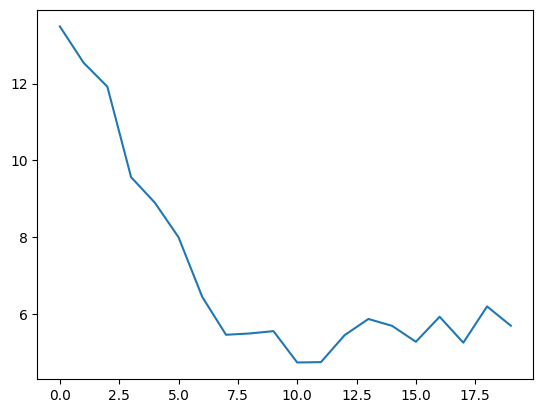

In [93]:
#mse 값들의 변화
plt.plot(test_history)
plt.show()


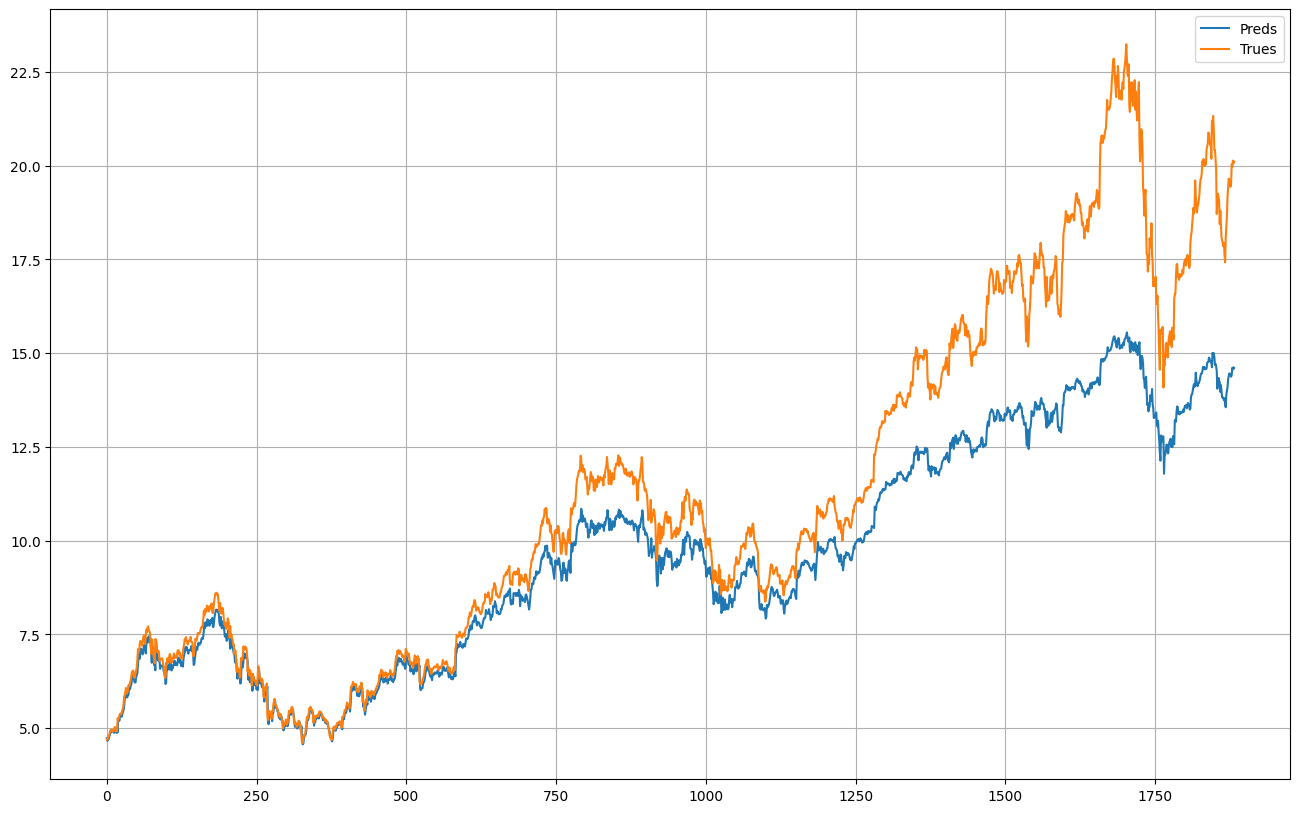

In [94]:
#검증 데이터를 이용하여 예측값을 생성하고 그래프 시각화
aapl_model.eval()

preds, trues=[],[]

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()
        pred=aapl_model(x)

        preds.append(pred.cpu())
        trues.append(y.cpu())

preds=torch.cat(preds, dim=0).squeeze(-1).numpy()
trues=torch.cat(trues, dim=0).squeeze(-1).numpy()

plt.figure(figsize=(16,10))
plt.plot(preds, label='Preds')
plt.plot(trues, label='Trues')
plt.legend()
plt.grid()
plt.show()